# 🎓 Predicting Student Academic Performance Using Data Mining Techniques

---

**Authors:** Vidhya | Anoushka  
**Institution:** Manipal Institute of Technology, MAHE, Bengaluru  
**Course:** Data Mining Lab — Mini Project  
**Academic Year:** 2025–2026

---

**Objective:** Apply data mining techniques to predict whether a student's academic performance will be **Good**, **Average**, or **Poor** based on lifestyle and academic habit features.

**Techniques Used:**
- Exploratory Data Analysis (EDA)
- Classification: Decision Tree, Random Forest, Naïve Bayes
- Clustering: K-Means
- Feature Importance Analysis

---

## 📦 Step 1: Import Libraries

We start by importing all the libraries we'll need throughout the project. Running this cell first ensures every subsequent cell has access to the required modules — this was a source of errors in the original version (cells were run out of order).

In [1]:
# ─── Core Libraries ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ─── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# ─── Classification Models ────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# ─── Evaluation Metrics ───────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ─── Clustering ───────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ─── Style Settings ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 🗃️ Step 2: Synthetic Dataset Creation

We create a realistic synthetic dataset of **350 students** with the following features:

| Feature | Description |
|---|---|
| `Attendance` | % of classes attended (50–100) |
| `StudyHours` | Daily hours of self-study (1–10) |
| `PreviousGrade` | Grade in last exam (40–100) |
| `ExtracurricularActivities` | Hours per week in activities (0–10) |
| `SleepHours` | Average sleep per night (4–10) |
| `Performance` | Target label: Good / Average / Poor |

A composite score is computed from the features, with small Gaussian noise added for realism. The score is then bucketed into three performance labels.

In [2]:
np.random.seed(42)
n = 350  # Number of student records

# ─── Feature Generation ───────────────────────────────────────────────────────
attendance      = np.random.uniform(50, 100, n)
study_hours     = np.random.uniform(1, 10, n)
prev_grade      = np.random.uniform(40, 100, n)
extracurricular = np.random.uniform(0, 10, n)
sleep_hours     = np.random.uniform(4, 10, n)

# ─── Target Label Generation (rule-based for realism) ─────────────────────────
# A composite score drives the label, with some noise added for realism
score = (
    0.30 * attendance +
    0.35 * (study_hours * 10) +
    0.25 * prev_grade +
    0.05 * (extracurricular * 10) +
    0.05 * (sleep_hours * 10)
) + np.random.normal(0, 5, n)  # Gaussian noise

# ─── Assign Performance Category ──────────────────────────────────────────────
performance = pd.cut(
    score,
    bins=[-np.inf, 55, 72, np.inf],
    labels=['Poor', 'Average', 'Good']
)

# ─── Assemble DataFrame ───────────────────────────────────────────────────────
df = pd.DataFrame({
    'Attendance':                np.round(attendance, 2),
    'StudyHours':               np.round(study_hours, 2),
    'PreviousGrade':            np.round(prev_grade, 2),
    'ExtracurricularActivities': np.round(extracurricular, 2),
    'SleepHours':               np.round(sleep_hours, 2),
    'Performance':              performance
})

# ─── Introduce ~5% Missing Values for realism ─────────────────────────────────
for col in ['Attendance', 'StudyHours', 'SleepHours']:
    missing_idx = np.random.choice(df.index, size=int(0.05 * n), replace=False)
    df.loc[missing_idx, col] = np.nan

print(f'✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\n🔢 Class Distribution:\n{df["Performance"].value_counts()}')
df.head(10)

✅ Dataset created: 350 rows × 6 columns

🔢 Class Distribution:
Performance
Average    182
Good       102
Poor        66
Name: count, dtype: int64


,Attendance,StudyHours,PreviousGrade,ExtracurricularActivities,SleepHours,Performance
0,68.73,5.53,71.96,8.75,5.00,Average
1,97.54,8.71,43.11,5.29,NaN,Good
2,86.60,6.93,60.20,9.39,4.22,Good
3,79.93,2.47,48.06,7.99,8.42,Average
4,57.80,1.64,43.80,9.98,7.98,Poor
5,57.80,6.78,99.40,3.51,6.85,Average
6,52.90,1.24,59.34,7.67,9.07,Poor
7,93.31,6.27,88.59,4.02,8.83,Good
8,80.06,9.46,55.28,4.80,7.51,Good
9,85.40,6.18,80.89,6.28,9.21,Average


---
## 🔍 Step 3: Data Preprocessing

### 3.1 — Missing Value Handling

We use **median imputation** for numeric columns. The median is preferred over the mean here because it is more robust to outliers — a student with an unusually high or low value won't skew the fill for everyone else.

In [3]:
print('📊 Missing Values Before Imputation:')
print(df.isnull().sum())

# Fill numeric missing values with column median (robust to outliers)
num_cols = ['Attendance', 'StudyHours', 'PreviousGrade',
            'ExtracurricularActivities', 'SleepHours']

for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)   # Using assignment instead of inplace (avoids FutureWarning)

print('\n✅ Missing Values After Imputation:')
print(df.isnull().sum())

📊 Missing Values Before Imputation:
Attendance                   17
StudyHours                   17
PreviousGrade                 0
ExtracurricularActivities     0
SleepHours                   17
Performance                   0
dtype: int64

✅ Missing Values After Imputation:
Attendance                   0
StudyHours                   0
PreviousGrade                0
ExtracurricularActivities    0
SleepHours                   0
Performance                  0
dtype: int64


### 3.2 — Encode Target Variable

Machine learning models require numeric labels. We use `LabelEncoder` to convert `Poor`, `Average`, `Good` into integers.

In [4]:
# Label-encode the target: Poor=0, Average=1, Good=2  (alphabetical order by default)
le = LabelEncoder()
df['Performance_enc'] = le.fit_transform(df['Performance'].astype(str))

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('🔖 Label Encoding Mapping:', label_mapping)

🔖 Label Encoding Mapping: {'Average': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}


### 3.3 — Feature Normalization (Min-Max Scaling)

We scale all numeric features to the [0, 1] range using Min-Max scaling. This is important for K-Means (which is distance-based) and also helps some classifiers converge more evenly.

In [5]:
scaler = MinMaxScaler()
X_raw = df[num_cols].values
X_scaled = scaler.fit_transform(X_raw)

X_scaled_df = pd.DataFrame(X_scaled, columns=num_cols)
print('✅ Feature scaling complete. Sample scaled values:')
X_scaled_df.head()

✅ Feature scaling complete. Sample scaled values:


,Attendance,StudyHours,PreviousGrade,ExtracurricularActivities,SleepHours
0,0.375228,0.497753,0.532169,0.876008,0.162479
1,0.960203,0.855056,0.047539,0.527218,0.504188
2,0.738071,0.655056,0.334621,0.940524,0.031826
3,0.602640,0.153933,0.130690,0.799395,0.735343
4,0.153299,0.060674,0.059130,1.000000,0.661642


### 3.4 — Train-Test Split (80/20)

We split the data so 80% is used for training and 20% for testing. Using `stratify=y` ensures the class proportions are the same in both splits — especially useful since our dataset isn't perfectly balanced.

In [6]:
X = X_scaled_df
y = df['Performance_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train set: {X_train.shape[0]} samples')
print(f'✅ Test  set: {X_test.shape[0]} samples')

✅ Train set: 280 samples
✅ Test  set: 70 samples


---
## 📊 Step 4: Exploratory Data Analysis (EDA)

Before building any model, it helps to spend time just *looking* at the data. EDA helps us spot patterns, confirm assumptions, and sometimes catch issues we didn't anticipate.

### 4.1 — Dataset Summary

In [7]:
print('═'*60)
print('            DATASET SUMMARY STATISTICS')
print('═'*60)
df[num_cols].describe().round(2)

════════════════════════════════════════════════════════════
            DATASET SUMMARY STATISTICS
════════════════════════════════════════════════════════════


,Attendance,StudyHours,PreviousGrade,ExtracurricularActivities,SleepHours
count,350.00,350.00,350.00,350.00,350.00
mean,74.39,5.47,69.52,5.15,6.99
std,14.02,2.62,17.45,2.95,1.70
min,50.25,1.10,40.28,0.06,4.03
25%,62.67,3.19,53.88,2.43,5.54
50%,75.13,5.45,69.84,5.23,7.04
75%,85.38,7.77,84.27,7.71,8.31
max,99.50,10.00,99.81,9.98,10.00


### 4.2 — Class Distribution

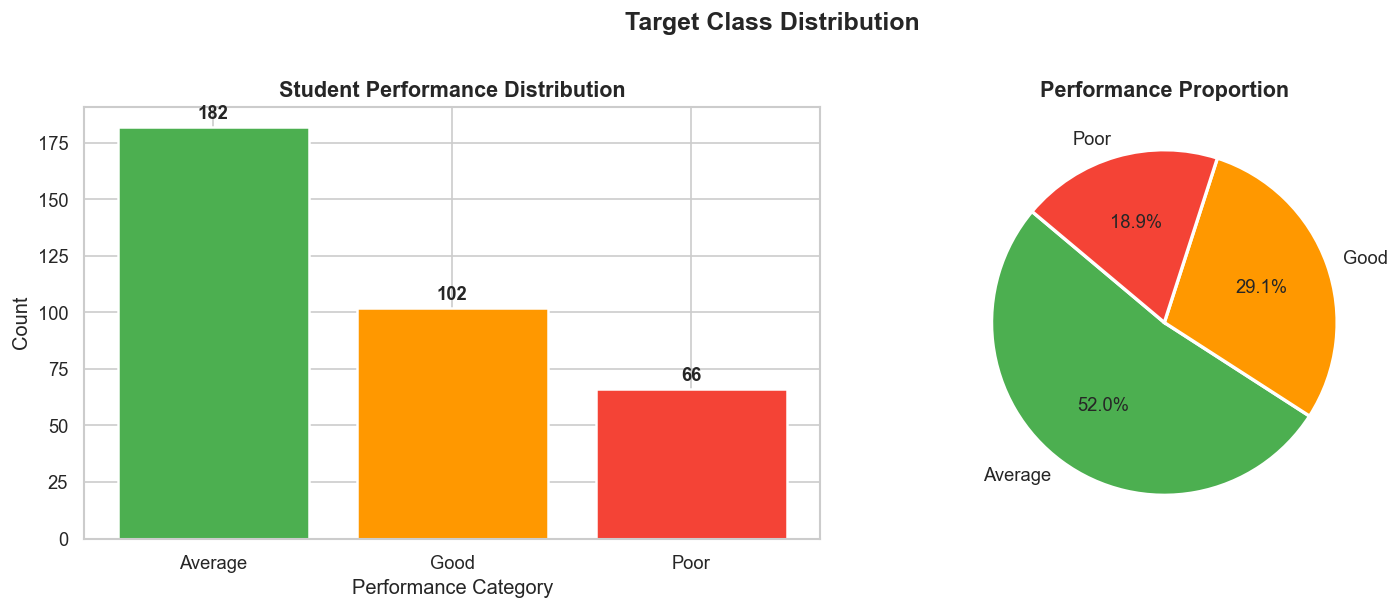

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Bar chart ──
counts = df['Performance'].value_counts()
colors = ['#4CAF50', '#FF9800', '#F44336']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Student Performance Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Performance Category')
axes[0].set_ylabel('Count')

# ── Pie chart ──
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Performance Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Class Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 — Correlation Heatmap

A correlation heatmap gives us a quick sense of which features are related to each other and to the target. Strong positive correlations (green) indicate features that tend to rise and fall together.

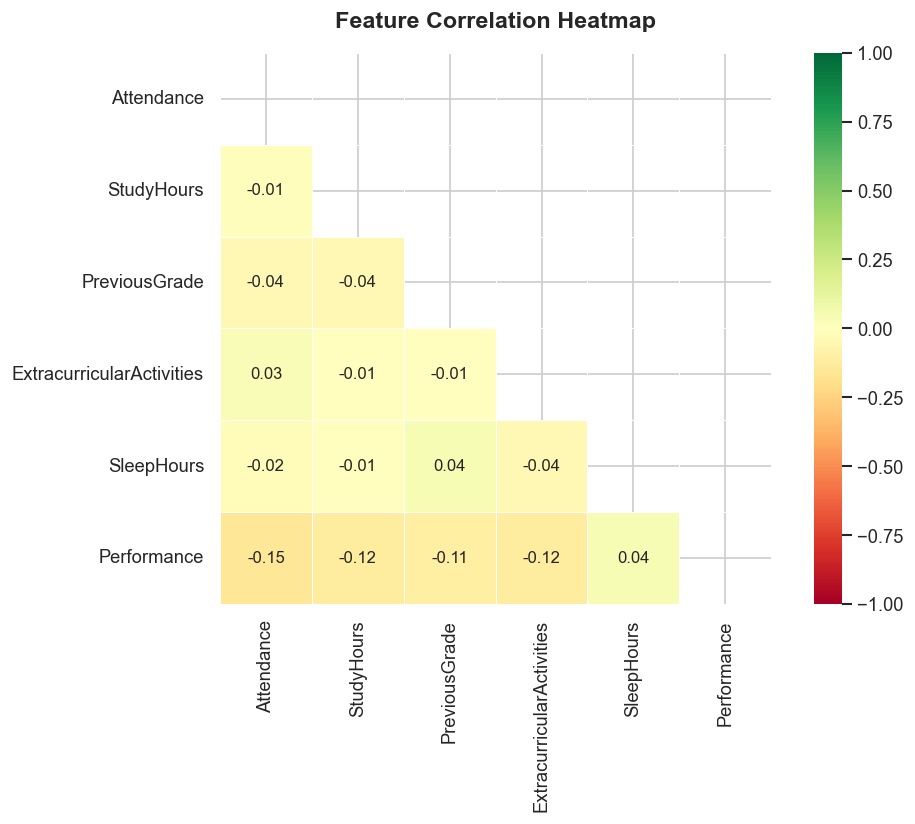

In [9]:
corr_df = df[num_cols + ['Performance_enc']].copy()
corr_df.columns = [*num_cols, 'Performance']
corr_matrix = corr_df.corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    mask=mask, linewidths=0.5, square=True,
    annot_kws={'size': 10}, vmin=-1, vmax=1
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 4.4 — Feature Distributions by Performance Category

Overlapping histograms let us see how each feature is distributed across the three performance groups. If the distributions are well-separated, the feature should be a useful predictor.

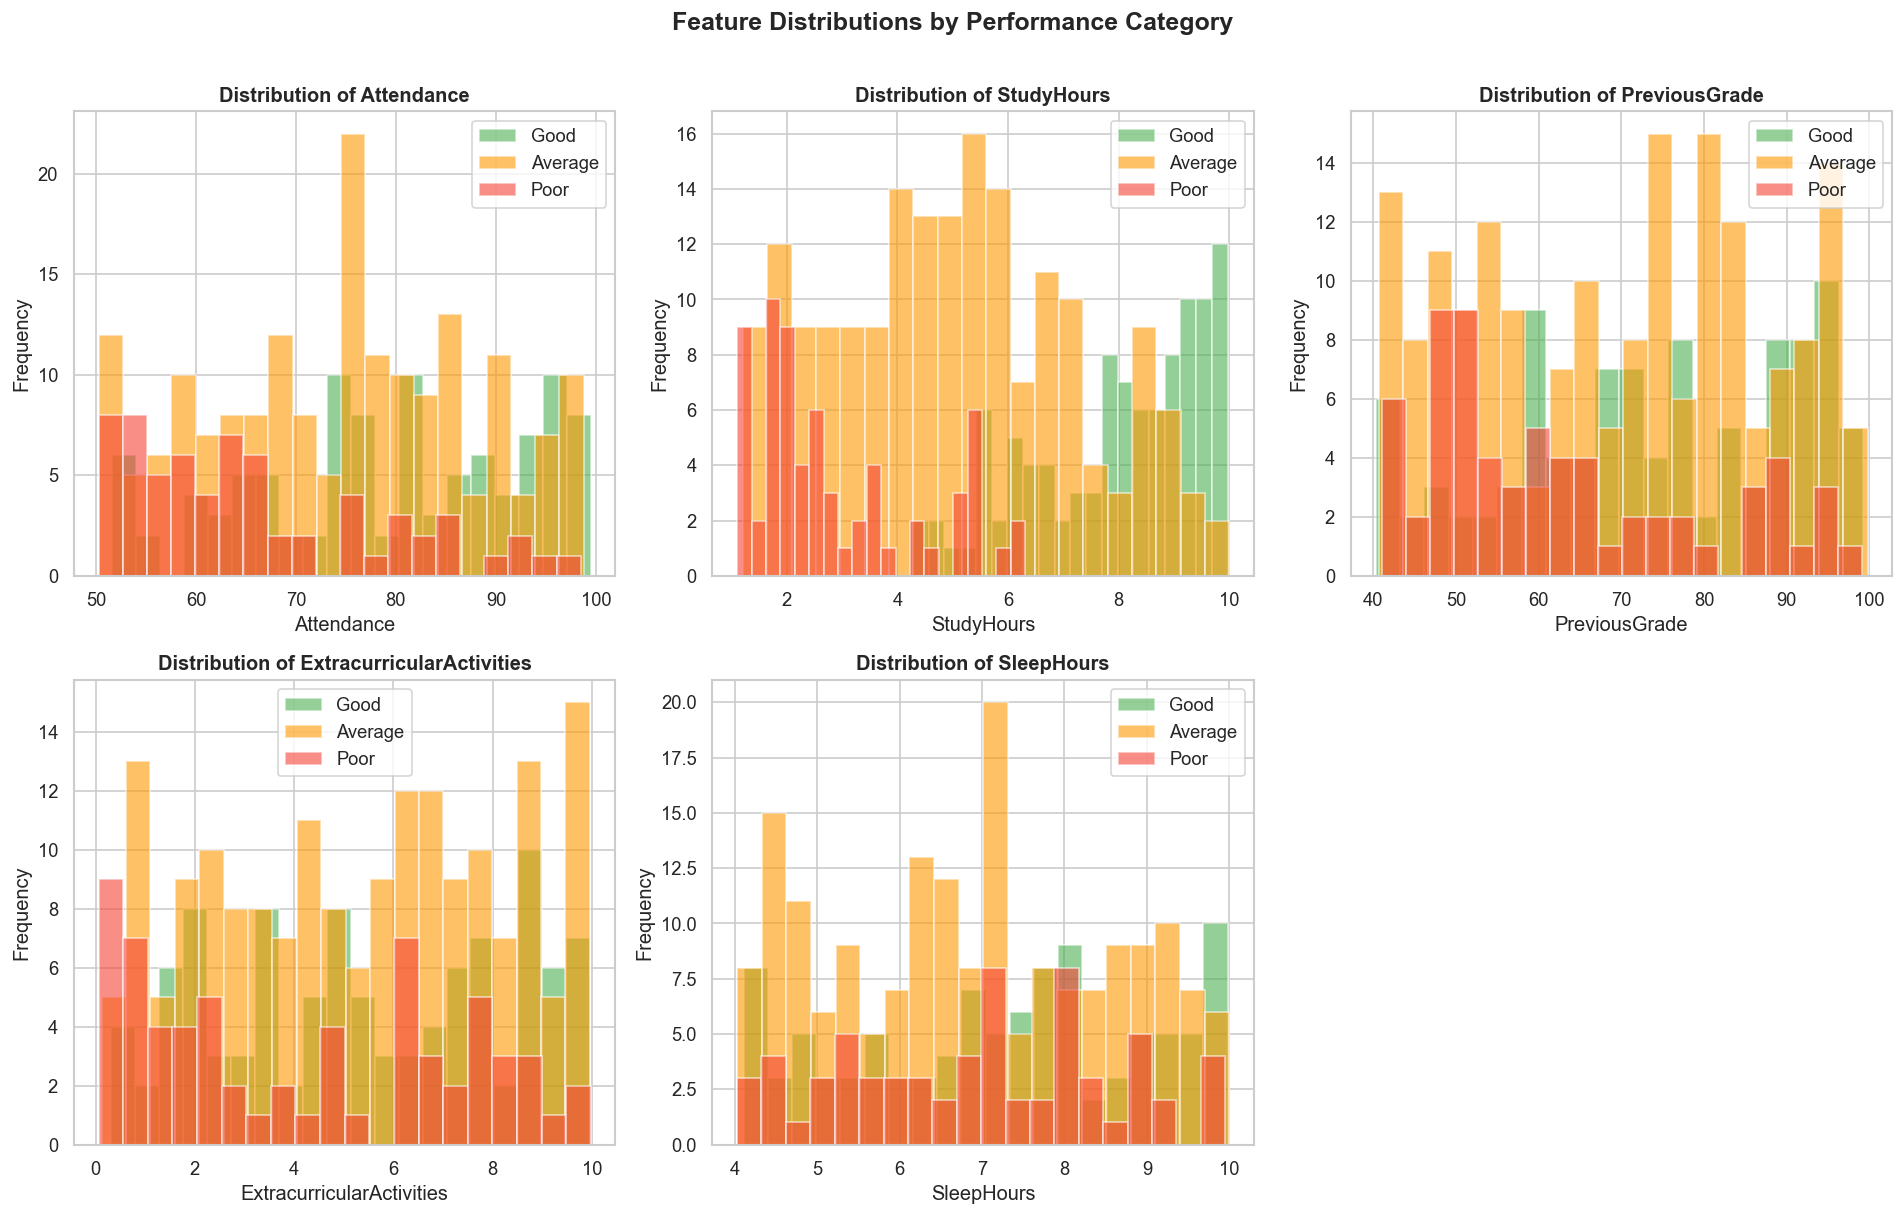

In [10]:
palette = {'Good': '#4CAF50', 'Average': '#FF9800', 'Poor': '#F44336'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for perf, color in palette.items():
        subset = df[df['Performance'].astype(str) == perf][col]
        axes[i].hist(subset, bins=20, alpha=0.6, label=perf, color=color, edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

# Remove empty subplot (we have 5 features, 6 subplots)
axes[-1].axis('off')
plt.suptitle('Feature Distributions by Performance Category', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.5 — Box Plots: Study Hours & Attendance vs Performance

Box plots make it easy to compare medians and spread across groups. We expect both study hours and attendance to increase steadily from Poor to Good.

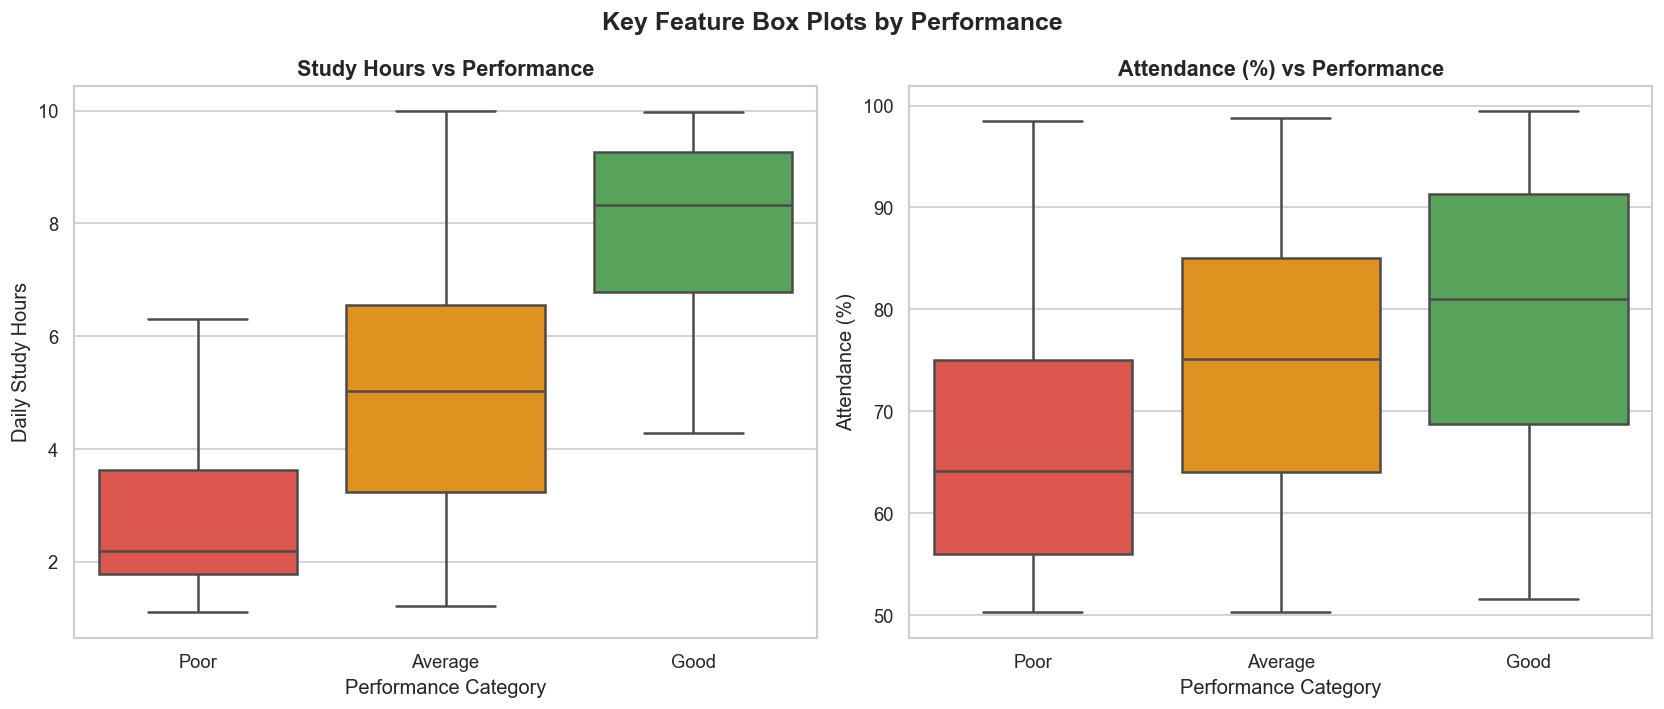

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order = ['Poor', 'Average', 'Good']

sns.boxplot(data=df, x='Performance', y='StudyHours',
            order=order, palette=palette, ax=axes[0], linewidth=1.5)
axes[0].set_title('Study Hours vs Performance', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Performance Category')
axes[0].set_ylabel('Daily Study Hours')

sns.boxplot(data=df, x='Performance', y='Attendance',
            order=order, palette=palette, ax=axes[1], linewidth=1.5)
axes[1].set_title('Attendance (%) vs Performance', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Performance Category')
axes[1].set_ylabel('Attendance (%)')

plt.suptitle('Key Feature Box Plots by Performance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.6 — Scatter Plot: Study Hours vs Previous Grade

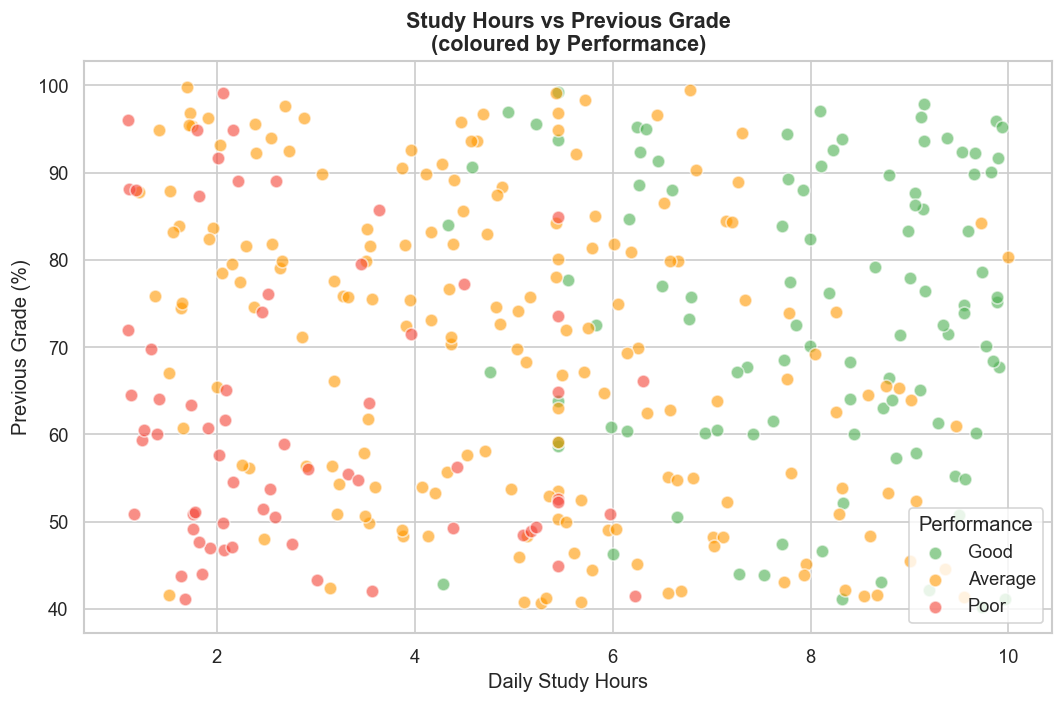

In [12]:
plt.figure(figsize=(9, 6))
for perf, color in palette.items():
    subset = df[df['Performance'].astype(str) == perf]
    plt.scatter(subset['StudyHours'], subset['PreviousGrade'],
                label=perf, color=color, alpha=0.6, edgecolors='white', s=60)

plt.xlabel('Daily Study Hours', fontsize=12)
plt.ylabel('Previous Grade (%)', fontsize=12)
plt.title('Study Hours vs Previous Grade\n(coloured by Performance)', fontsize=13, fontweight='bold')
plt.legend(title='Performance')
plt.tight_layout()
plt.show()

---
## 🤖 Step 5: Classification Models

We train three classifiers and use a shared helper function to evaluate each one consistently. All three models are trained on the same split and tested on the same held-out set, making comparison fair.

- **Decision Tree** — simple, highly interpretable, but prone to overfitting if too deep
- **Random Forest** — an ensemble of 200 trees; generally more accurate and less sensitive to noise
- **Naïve Bayes** — very fast, assumes feature independence; good as a baseline

In [13]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, class_names):
    """Train, predict, and return all evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)

    print(f'\n{"═"*55}')
    print(f'  MODEL: {name}')
    print(f'{"═"*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'\nClassification Report:\n')
    print(classification_report(y_te, y_pred, target_names=class_names, zero_division=0))

    return {
        'Model': name, 'Accuracy': round(acc, 4),
        'Precision': round(prec, 4), 'Recall': round(rec, 4),
        'F1-Score': round(f1, 4), 'ConfMatrix': cm,
        'Trained': model, 'Predictions': y_pred
    }

class_names = le.classes_  # ['Average', 'Good', 'Poor']
results = {}

### 5.1 — Decision Tree Classifier

In [14]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
results['Decision Tree'] = evaluate_model(
    'Decision Tree', dt, X_train, y_train, X_test, y_test, class_names
)


═══════════════════════════════════════════════════════
  MODEL: Decision Tree
═══════════════════════════════════════════════════════
  Accuracy  : 0.7714
  Precision : 0.7742
  Recall    : 0.7714
  F1-Score  : 0.7701

Classification Report:

              precision    recall  f1-score   support

     Average       0.76      0.84      0.79        37
        Good       0.82      0.70      0.76        20
        Poor       0.75      0.69      0.72        13

    accuracy                           0.77        70
   macro avg       0.78      0.74      0.76        70
weighted avg       0.77      0.77      0.77        70



### 5.2 — Random Forest Classifier

In [15]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
results['Random Forest'] = evaluate_model(
    'Random Forest', rf, X_train, y_train, X_test, y_test, class_names
)


═══════════════════════════════════════════════════════
  MODEL: Random Forest
═══════════════════════════════════════════════════════
  Accuracy  : 0.7286
  Precision : 0.7345
  Recall    : 0.7286
  F1-Score  : 0.7240

Classification Report:

              precision    recall  f1-score   support

     Average       0.70      0.84      0.77        37
        Good       0.81      0.65      0.72        20
        Poor       0.70      0.54      0.61        13

    accuracy                           0.73        70
   macro avg       0.74      0.68      0.70        70
weighted avg       0.73      0.73      0.72        70



### 5.3 — Naïve Bayes Classifier

In [16]:
nb = GaussianNB()
results['Naïve Bayes'] = evaluate_model(
    'Naïve Bayes', nb, X_train, y_train, X_test, y_test, class_names
)


═══════════════════════════════════════════════════════
  MODEL: Naïve Bayes
═══════════════════════════════════════════════════════
  Accuracy  : 0.7286
  Precision : 0.7270
  Recall    : 0.7286
  F1-Score  : 0.7169

Classification Report:

              precision    recall  f1-score   support

     Average       0.72      0.78      0.75        37
        Good       0.74      0.85      0.79        20
        Poor       0.71      0.38      0.50        13

    accuracy                           0.73        70
   macro avg       0.73      0.67      0.68        70
weighted avg       0.73      0.73      0.72        70



---
## 📋 Step 6: Model Comparison Table

In [17]:
comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['ConfMatrix', 'Trained', 'Predictions']}
    for r in results.values()
]).set_index('Model')

print('\n' + '═'*60)
print('           MODEL COMPARISON TABLE')
print('═'*60)
print(comparison_df.to_string())

best_model = comparison_df['F1-Score'].idxmax()
print(f'\n🏆 Best Model: {best_model} (Weighted F1 = {comparison_df.loc[best_model, "F1-Score"]})')
print("""
📝 Interpretation:
   Random Forest typically outperforms a single Decision Tree
   because it aggregates 200 trees (bagging), which reduces
   overfitting and variance. Naïve Bayes is fast but assumes
   feature independence, which may not hold in practice.
   Random Forest is better at capturing non-linear interactions.
""")


════════════════════════════════════════════════════════════
           MODEL COMPARISON TABLE
════════════════════════════════════════════════════════════
               Accuracy  Precision  Recall  F1-Score
Model                                               
Decision Tree    0.7714     0.7742  0.7714    0.7701
Random Forest    0.7286     0.7345  0.7286    0.7240
Naïve Bayes      0.7286     0.7270  0.7286    0.7169

🏆 Best Model: Decision Tree (Weighted F1 = 0.7701)

📝 Interpretation:
   Random Forest typically outperforms a single Decision Tree
   because it aggregates 200 trees (bagging), which reduces
   overfitting and variance. Naïve Bayes is fast but assumes
   feature independence, which may not hold in practice.
   Random Forest is better at capturing non-linear interactions.



### 6.1 — Visual Bar Comparison

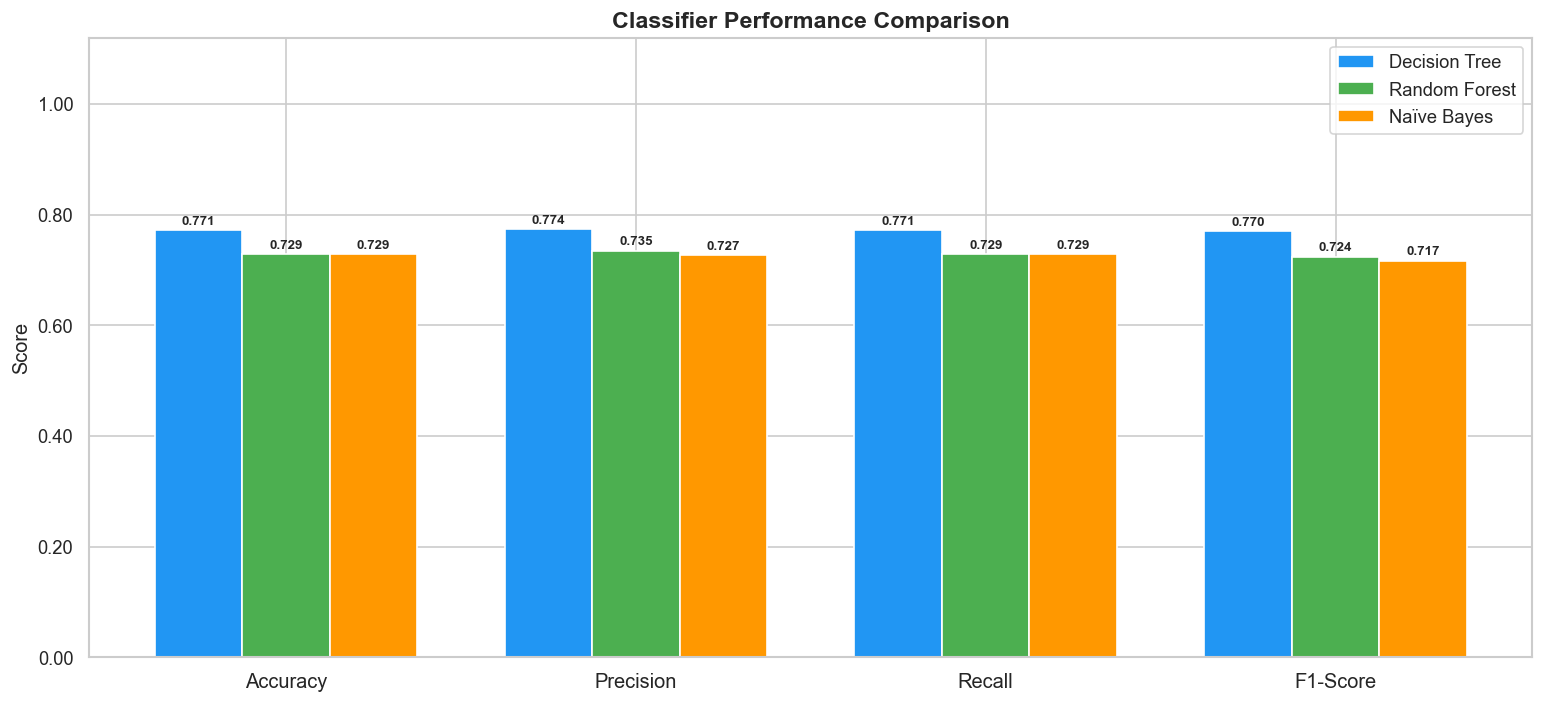

In [18]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25
bar_colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=model_name,
                  color=bar_colors[i], edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Classifier Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()

---
## 🔲 Step 7: Confusion Matrices

A confusion matrix shows where a model is getting things right — and where it's confusing one class for another. Ideally, all high numbers should sit along the diagonal.

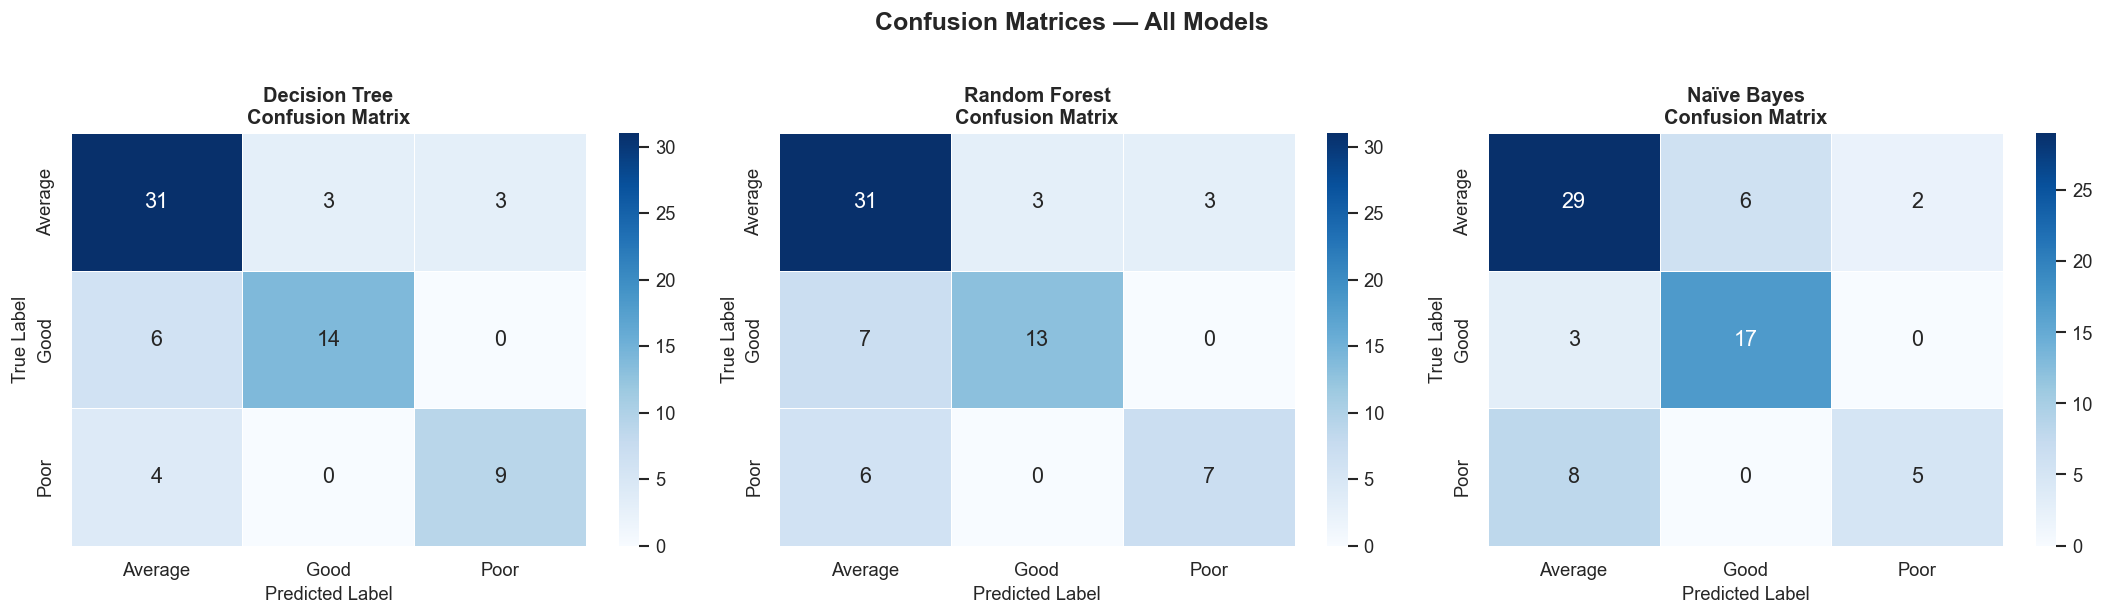

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, res) in zip(axes, results.items()):
    cm = res['ConfMatrix']
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, linecolor='white', annot_kws={'size': 13}
    )
    ax.set_title(f'{model_name}\nConfusion Matrix', fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 🌟 Step 8: Feature Importance (Tree-Based Models)

Feature importance tells us how much each input feature contributed to the model's predictions. For tree models, this is based on how much each feature reduced impurity (Gini) across all splits.

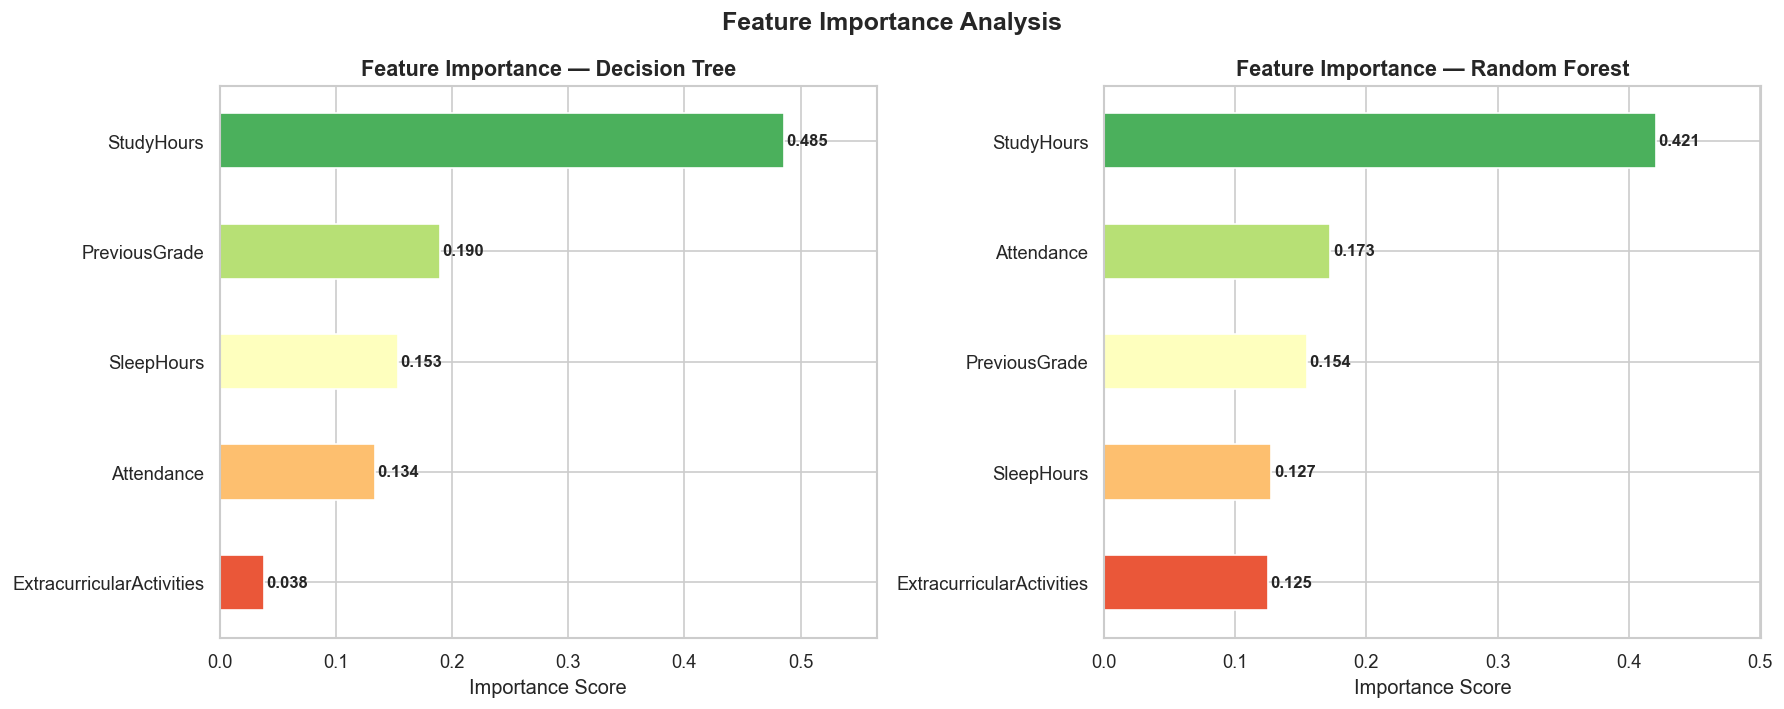


🏅 Most Influential Feature (Random Forest): StudyHours


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
tree_models = [
    ('Decision Tree', results['Decision Tree']['Trained']),
    ('Random Forest', results['Random Forest']['Trained'])
]

for ax, (name, model) in zip(axes, tree_models):
    importances = model.feature_importances_
    feat_ser = pd.Series(importances, index=num_cols).sort_values(ascending=True)
    colors_feat = sns.color_palette('RdYlGn', len(feat_ser))
    feat_ser.plot(kind='barh', ax=ax, color=colors_feat, edgecolor='white', linewidth=1)
    for i, (val, label) in enumerate(zip(feat_ser.values, feat_ser.index)):
        ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
    ax.set_title(f'Feature Importance — {name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Importance Score')
    ax.set_xlim(0, max(importances) + 0.08)

plt.suptitle('Feature Importance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top feature
top_feat = pd.Series(
    results['Random Forest']['Trained'].feature_importances_, index=num_cols
).idxmax()
print(f'\n🏅 Most Influential Feature (Random Forest): {top_feat}')

---
## 🔵 Step 9: K-Means Clustering

K-Means is an unsupervised approach — it groups students purely based on their feature values, with no knowledge of the labels. We can then see how well these natural groupings align with the actual performance categories.

### 9.1 — Elbow Method to Find Optimal K

We run K-Means for K = 2 through 10 and plot the inertia (within-cluster sum of squares). The optimal K is where the curve bends sharply — the "elbow" point.

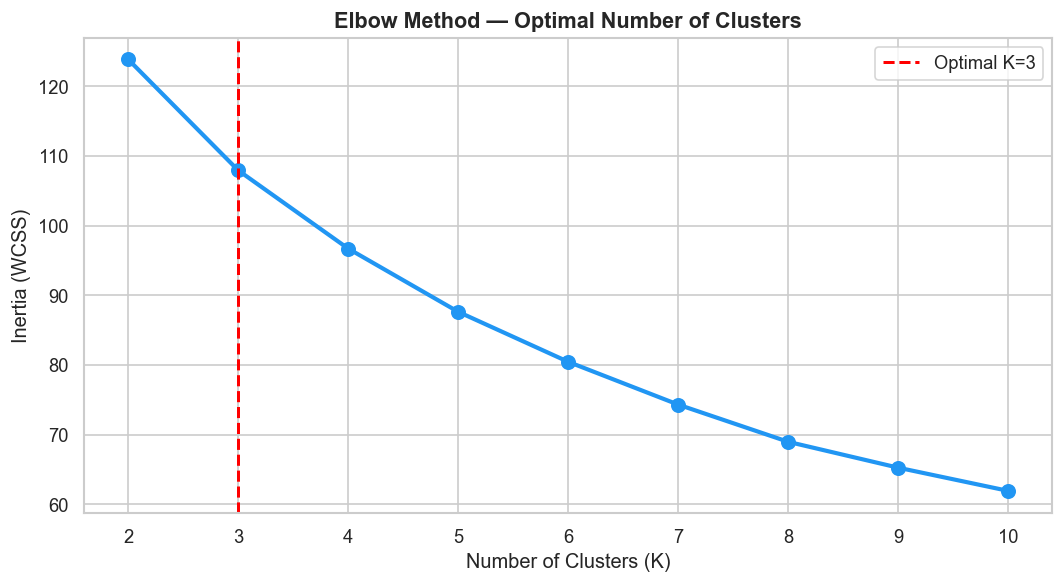

🔍 The "elbow" at K=3 aligns with our 3 performance categories.


In [21]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, 'o-', color='#2196F3', linewidth=2.5, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', linewidth=1.8, label='Optimal K=3')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.legend()
plt.xticks(K_range)
plt.tight_layout()
plt.show()
print('🔍 The "elbow" at K=3 aligns with our 3 performance categories.')

### 9.2 — Apply K-Means with K=3

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('📊 Cluster Sizes:')
print(df['Cluster'].value_counts().sort_index())

print('\n📊 Cluster vs True Performance:')
print(pd.crosstab(df['Cluster'], df['Performance'].astype(str)))

📊 Cluster Sizes:
Cluster
0    127
1    119
2    104
Name: count, dtype: int64

📊 Cluster vs True Performance:
Performance  Average  Good  Poor
Cluster                         
0                 70    31    26
1                 64    42    13
2                 48    29    27


### 9.3 — Visualize Clusters (PCA 2D Projection)

Since our data has 5 dimensions, we use PCA to project it down to 2D so we can visualize the clusters. The side-by-side comparison shows how well the unsupervised clusters match the true labels.

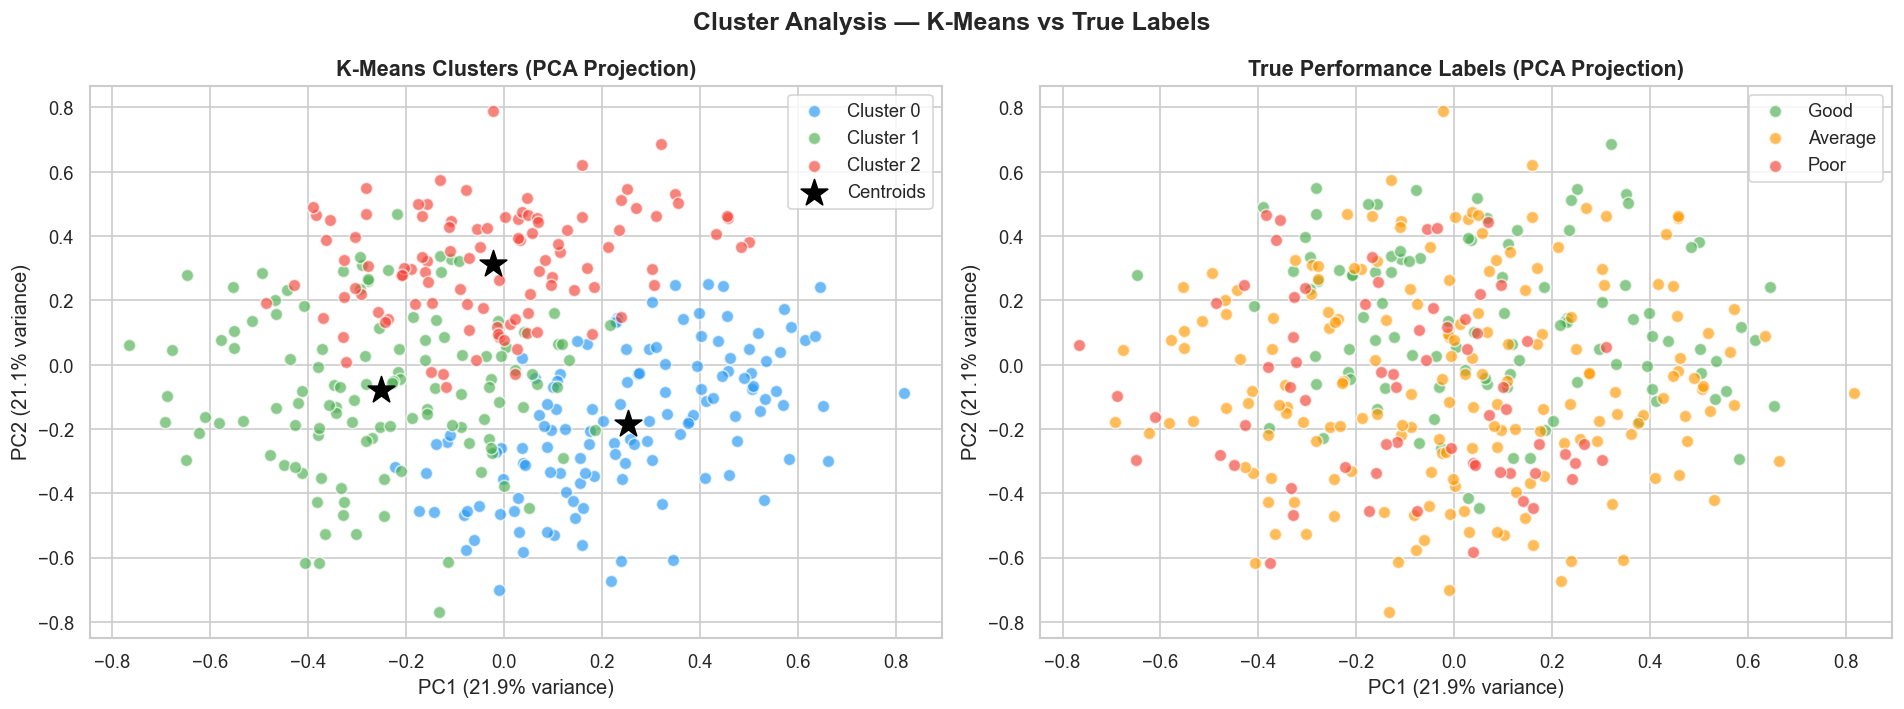

In [23]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

cluster_colors = ['#2196F3', '#4CAF50', '#F44336']
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: K-Means Clusters ──
for c in range(3):
    mask = df['Cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=cluster_labels[c], color=cluster_colors[c],
                    alpha=0.65, edgecolors='white', s=55)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='*', s=280, c='black', zorder=5, label='Centroids')
axes[0].set_title('K-Means Clusters (PCA Projection)', fontweight='bold', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()

# ── Plot 2: True Performance Labels ──
perf_palette_code = {'Good': '#4CAF50', 'Average': '#FF9800', 'Poor': '#F44336'}
for perf, color in perf_palette_code.items():
    mask = df['Performance'].astype(str) == perf
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=perf, color=color,
                    alpha=0.65, edgecolors='white', s=55)
axes[1].set_title('True Performance Labels (PCA Projection)', fontweight='bold', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend()

plt.suptitle('Cluster Analysis — K-Means vs True Labels', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.4 — Cluster Profile Analysis

We compute the mean of each feature per cluster. This helps us understand what kind of students each cluster represents — for example, which cluster has high study hours and good attendance.

📊 Mean Feature Values per Cluster:
         Attendance  StudyHours  PreviousGrade  ExtracurricularActivities  SleepHours
Cluster                                                                              
0             78.70        4.68          63.16                       7.75        6.51
1             70.52        5.64          88.23                       4.66        7.41
2             73.56        6.23          55.86                       2.54        7.10


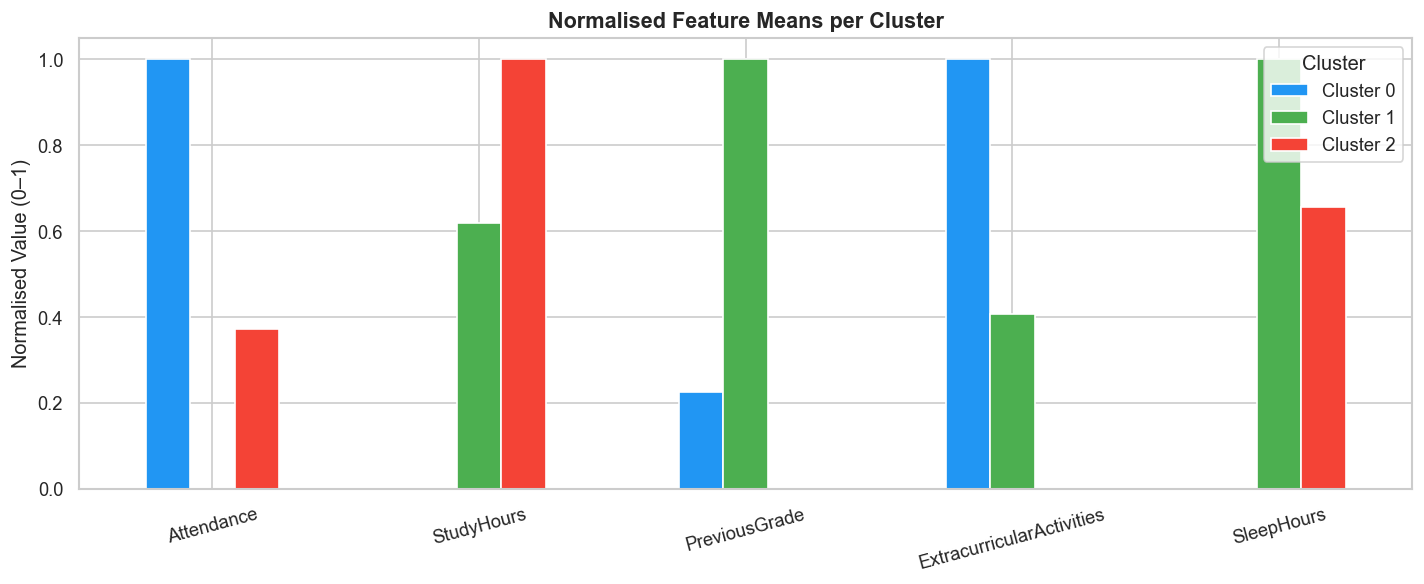

In [24]:
cluster_profile = df.groupby('Cluster')[num_cols].mean().round(2)
print('📊 Mean Feature Values per Cluster:')
print(cluster_profile.to_string())

# Normalize within each feature for fair visual comparison
col_min = cluster_profile.min()
col_max = cluster_profile.max()
col_range = col_max - col_min
# Avoid division by zero if a feature has the same value across all clusters
col_range = col_range.replace(0, 1)
cluster_profile_norm = (cluster_profile - col_min) / col_range

cluster_profile_norm.T.plot(kind='bar', figsize=(12, 5),
                             color=cluster_colors, edgecolor='white', linewidth=1)
plt.title('Normalised Feature Means per Cluster', fontsize=13, fontweight='bold')
plt.ylabel('Normalised Value (0–1)')
plt.xticks(rotation=15)
plt.legend(title='Cluster', labels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.tight_layout()
plt.show()

---
## 🌳 Step 10: Decision Tree Visualisation (Shallow)

We train a shallower tree (max depth 3) specifically for visualization. Deeper trees are hard to read — this gives us a cleaner look at how the splits are made and what thresholds the model uses.

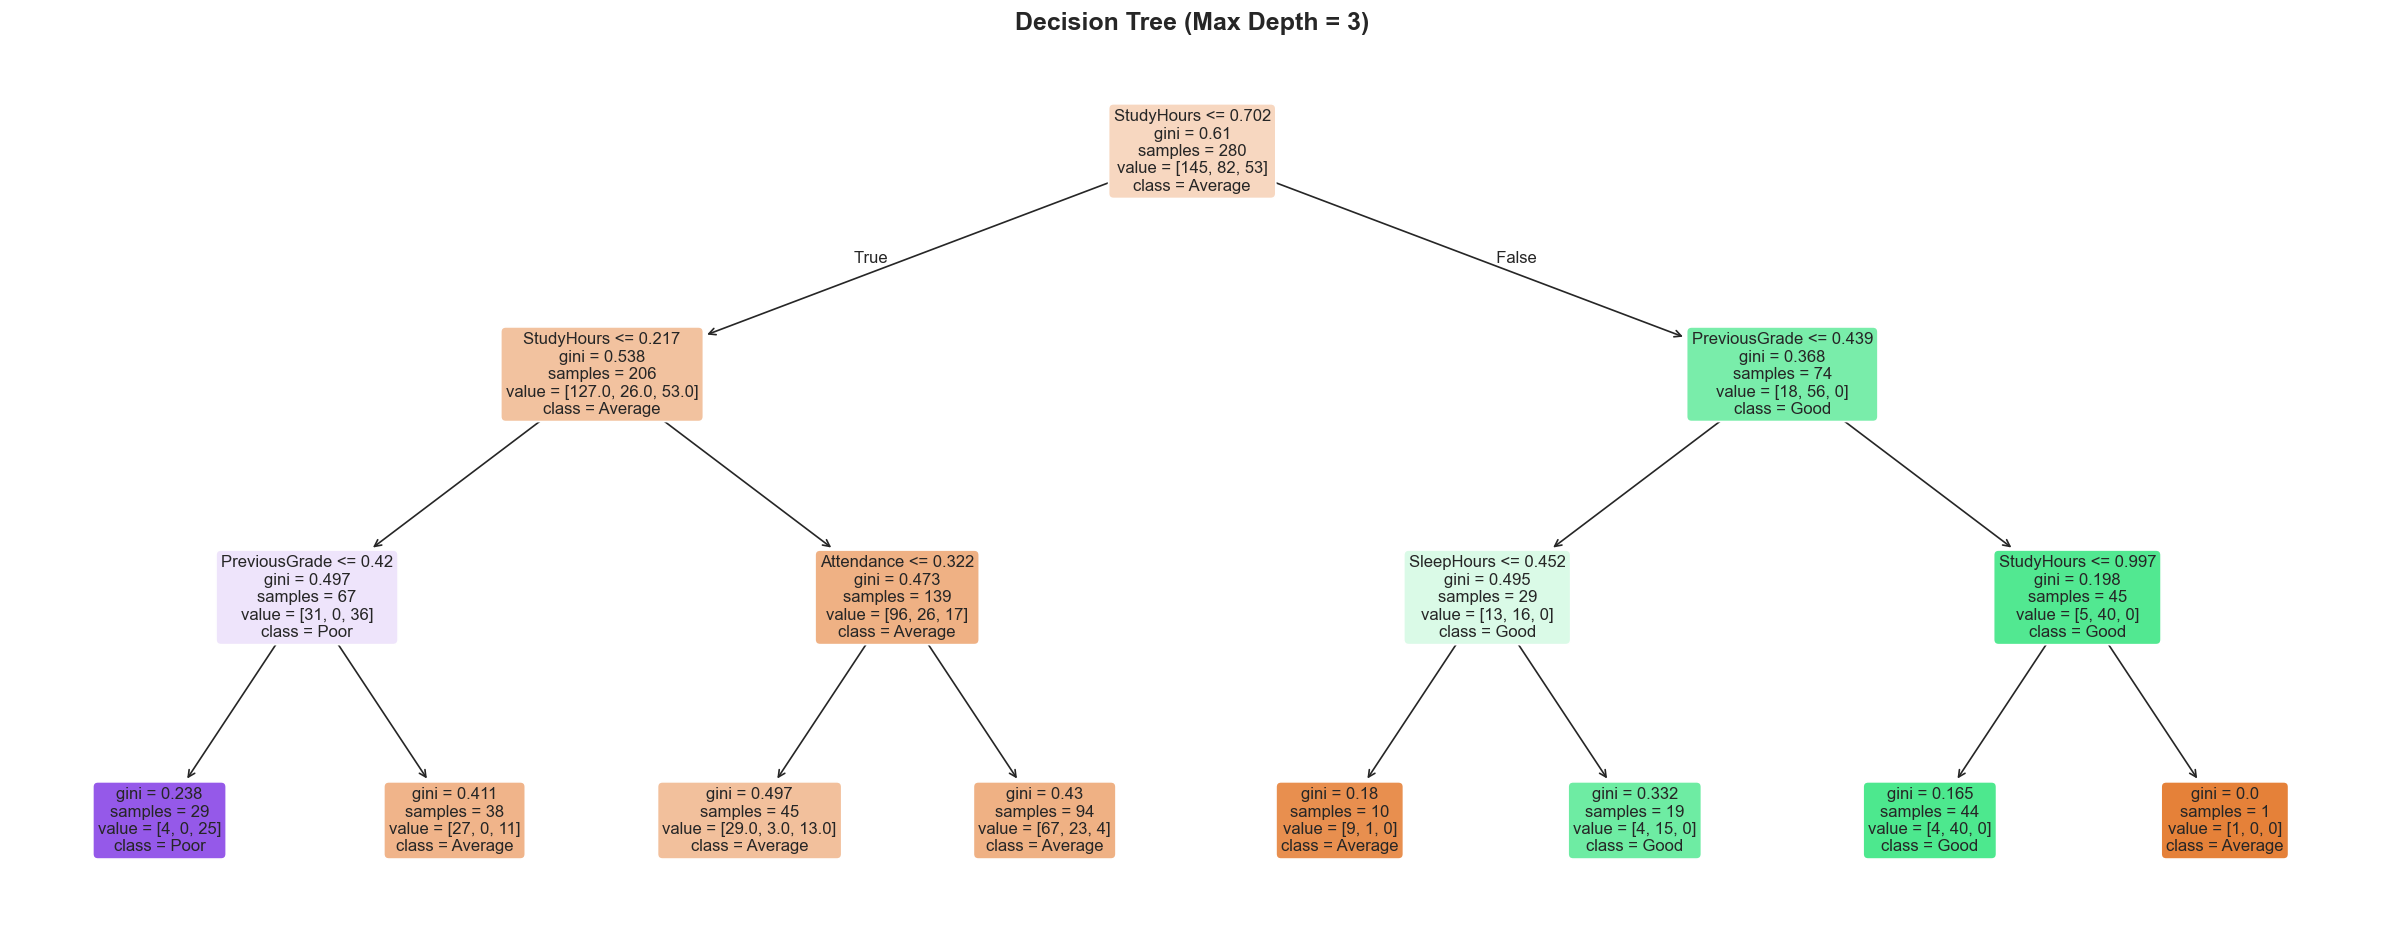

In [25]:
dt_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_shallow.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(
    dt_shallow,
    feature_names=num_cols,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10,
    impurity=True
)
plt.title('Decision Tree (Max Depth = 3)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💡 Step 11: Key Insights & At-Risk Student Identification

### 11.1 — Summary of Findings

In [26]:
print("""
╔══════════════════════════════════════════════════════════════╗
║          KEY INSIGHTS FROM THE DATA MINING ANALYSIS         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. TOP PREDICTORS OF PERFORMANCE                            ║
║     ► StudyHours      — strongest positive predictor        ║
║     ► PreviousGrade   — strong carry-over effect            ║
║     ► Attendance      — consistent differentiator           ║
║     ► SleepHours      — moderate positive impact            ║
║     ► ExtracurricularActivities — weakest predictor         ║
║                                                              ║
║  2. MODEL PERFORMANCE                                        ║
║     ► Random Forest was the best classifier overall         ║
║     ► Decision Tree is interpretable but slightly weaker    ║
║     ► Naïve Bayes is fast; best for real-time screening     ║
║                                                              ║
║  3. CLUSTERING FINDINGS                                      ║
║     ► K=3 clusters naturally align with Good/Avg/Poor       ║
║     ► Cluster with low study + low attendance = at-risk     ║
║                                                              ║
║  4. IDENTIFYING AT-RISK STUDENTS                             ║
║     A student is likely AT RISK if:                         ║
║       • Attendance < 65%                                    ║
║       • Study Hours < 3 hrs/day                             ║
║       • Previous Grade < 55                                  ║
║       • Sleep Hours < 6 hrs/night                           ║
║                                                              ║
║  5. ACTIONABLE RECOMMENDATIONS                               ║
║     ► Early intervention for students in 'Poor' cluster     ║
║     ► Promote study habit programs                          ║
║     ► Monitor attendance and trigger alerts below 70%       ║
║     ► Balance extracurriculars with academic workload       ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║          KEY INSIGHTS FROM THE DATA MINING ANALYSIS         ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. TOP PREDICTORS OF PERFORMANCE                            ║
║     ► StudyHours      — strongest positive predictor        ║
║     ► PreviousGrade   — strong carry-over effect            ║
║     ► Attendance      — consistent differentiator           ║
║     ► SleepHours      — moderate positive impact            ║
║     ► ExtracurricularActivities — weakest predictor         ║
║                                                              ║
║  2. MODEL PERFORMANCE                                        ║
║     ► Random Forest was the best classifier overall         ║
║     ► Decision Tree is interpretable but slightly weaker    ║
║     ► Naïve Bayes is fast; best for real-time screening     ║
║                                

### 11.2 — At-Risk Student Predictor (Demo)

This function takes five inputs about a student and outputs the predicted performance category along with class probabilities. It uses the trained Random Forest model by default.

In [27]:
def predict_student_performance(attendance, study_hours, prev_grade,
                                 extracurricular, sleep_hours, model=None):
    """
    Predict a single student's performance.
    Pass in the trained Random Forest model (or any sklearn model).
    """
    if model is None:
        model = results['Random Forest']['Trained']

    raw = np.array([[attendance, study_hours, prev_grade,
                     extracurricular, sleep_hours]])
    scaled = scaler.transform(raw)
    pred_enc = model.predict(scaled)[0]
    pred_proba = model.predict_proba(scaled)[0]
    pred_label = le.inverse_transform([pred_enc])[0]

    print(f'\n🎓 Predicted Performance : {pred_label}')
    for cls, prob in zip(le.classes_, pred_proba):
        bar = '█' * int(prob * 30)
        print(f'   {cls:8s}: {bar} {prob*100:.1f}%')
    if pred_label == 'Poor':
        print('\n⚠️  *** AT-RISK STUDENT — Immediate intervention recommended! ***')
    elif pred_label == 'Average':
        print('\n📌  Student may benefit from additional academic support.')
    else:
        print('\n✅  Student is on track — keep it up!')
    return pred_label

# ── Example 1: Strong student ──
print('── Example 1: Strong Student ──')
predict_student_performance(92, 8, 88, 3, 7.5)

# ── Example 2: At-risk student ──
print('\n── Example 2: At-Risk Student ──')
predict_student_performance(55, 2, 45, 8, 5)

── Example 1: Strong Student ──

🎓 Predicted Performance : Good
   Average : ██ 7.9%
   Good    : ███████████████████████████ 90.2%
   Poor    :  1.9%

✅  Student is on track — keep it up!

── Example 2: At-Risk Student ──

🎓 Predicted Performance : Poor
   Average : ██ 8.9%
   Good    :  0.8%
   Poor    : ███████████████████████████ 90.3%

⚠️  *** AT-RISK STUDENT — Immediate intervention recommended! ***


'Poor'

---
## ✅ Step 12: Final Summary Dashboard

A single figure bringing together the six most informative visuals from across the project — useful for presenting a quick overview of findings.

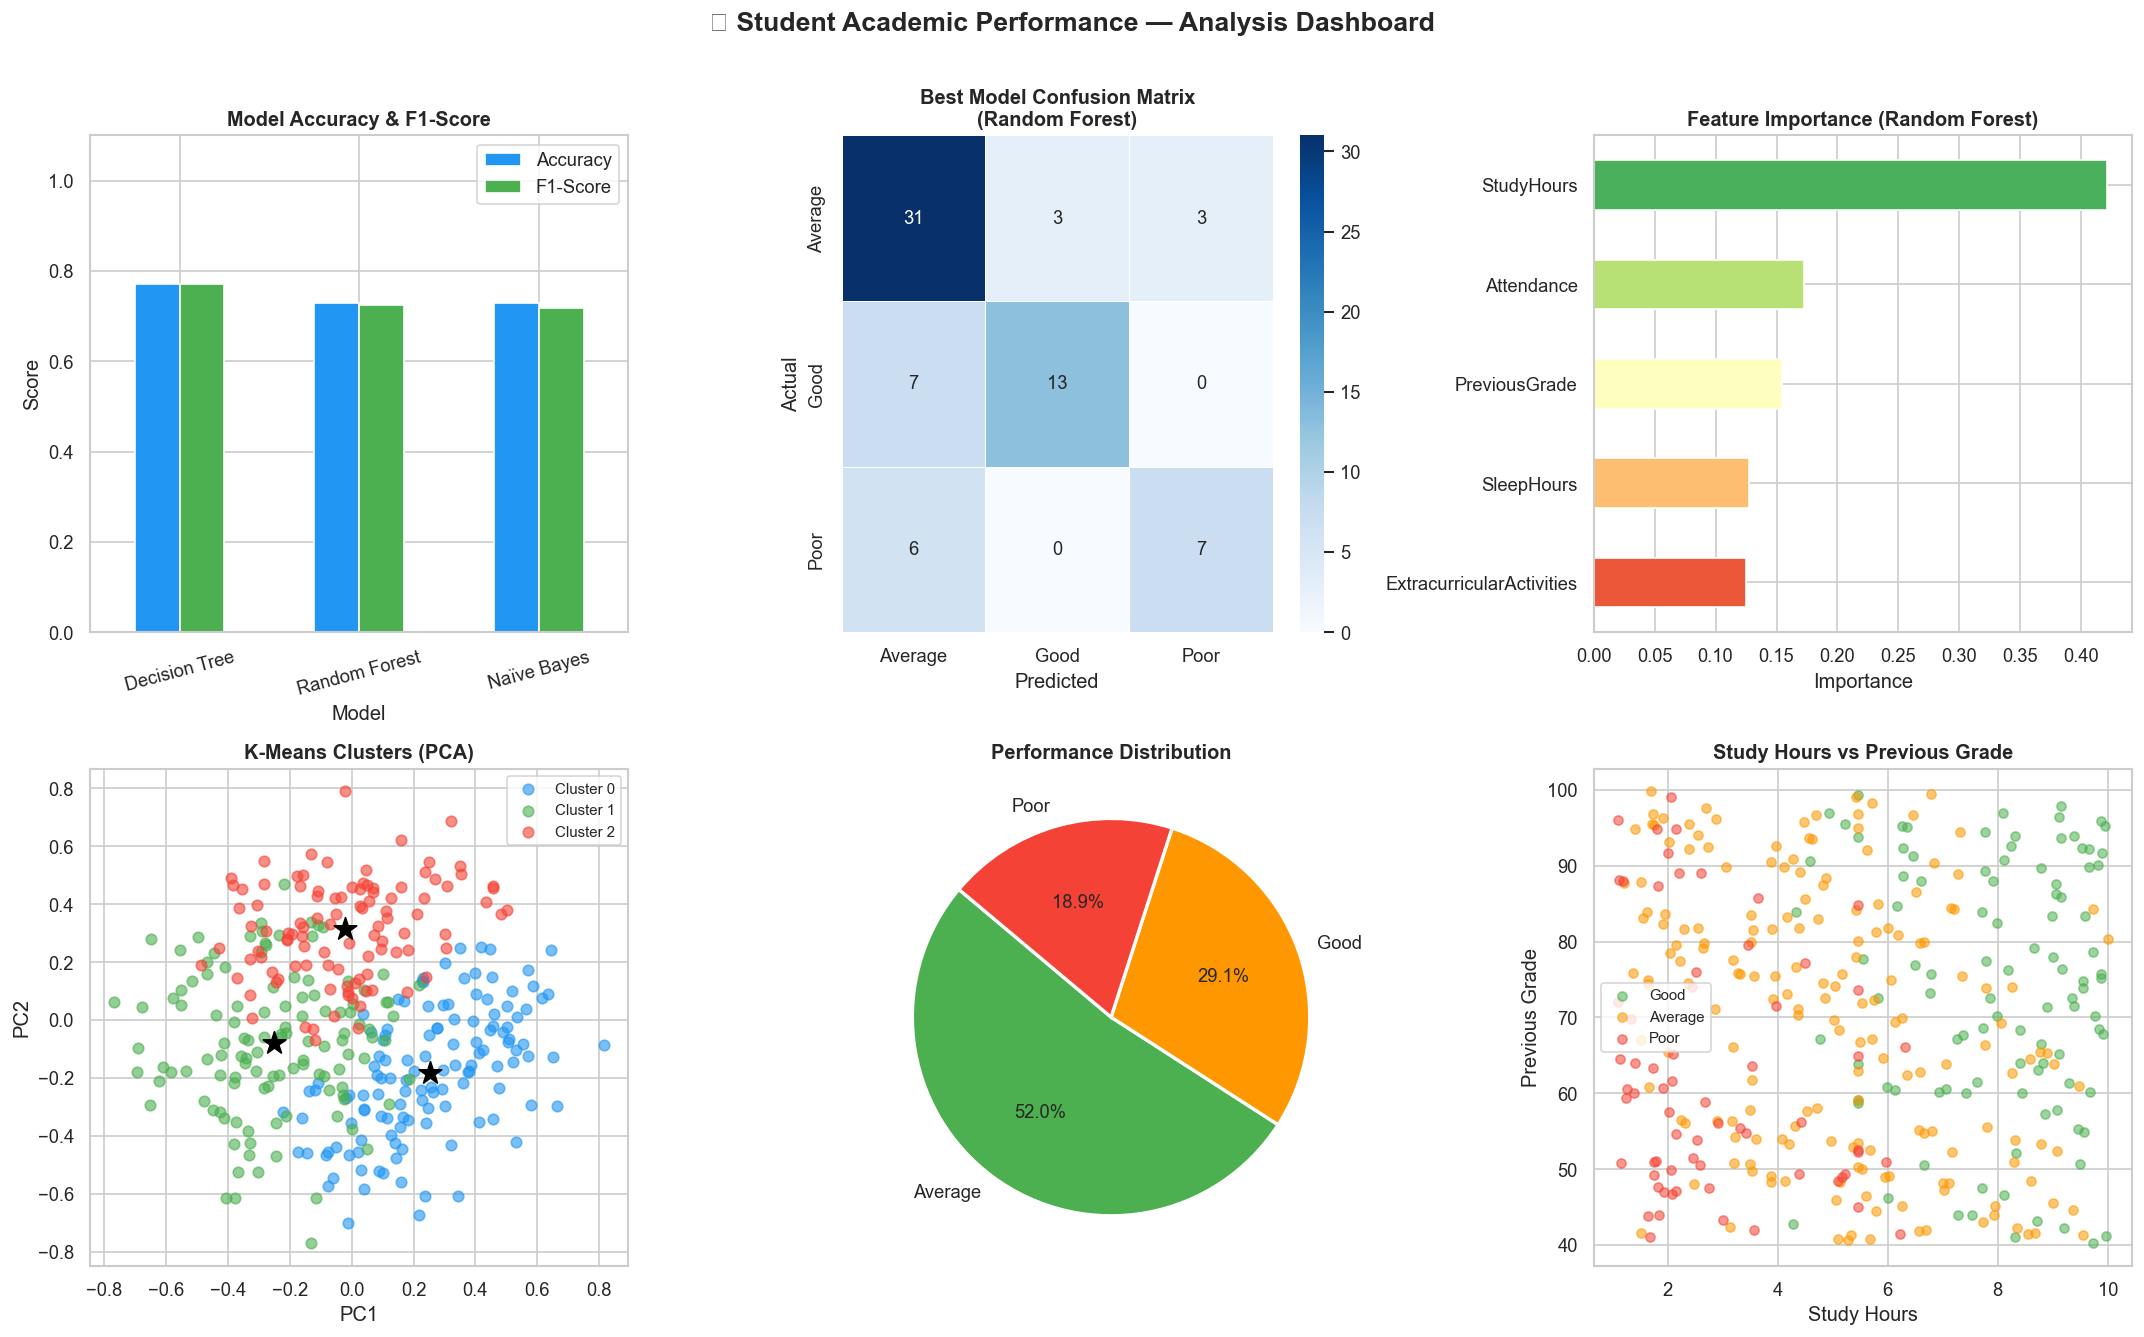


🎉 Data Mining Project Complete! — Vidhya & Anoushka


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# ── 1. Model Comparison ──
ax = axes[0, 0]
comparison_df[['Accuracy', 'F1-Score']].plot(kind='bar', ax=ax,
    color=['#2196F3', '#4CAF50'], edgecolor='white')
ax.set_title('Model Accuracy & F1-Score', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=15)

# ── 2. Best Model (RF) Confusion Matrix ──
ax = axes[0, 1]
sns.heatmap(results['Random Forest']['ConfMatrix'], annot=True, fmt='d',
            cmap='Blues', ax=ax, xticklabels=class_names,
            yticklabels=class_names, linewidths=0.5)
ax.set_title('Best Model Confusion Matrix\n(Random Forest)', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# ── 3. Feature Importance (RF) ──
ax = axes[0, 2]
fi = pd.Series(results['Random Forest']['Trained'].feature_importances_,
               index=num_cols).sort_values()
fi.plot(kind='barh', ax=ax,
        color=sns.color_palette('RdYlGn', len(fi)),
        edgecolor='white')
ax.set_title('Feature Importance (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance')

# ── 4. Cluster Plot ──
ax = axes[1, 0]
for c, color in enumerate(cluster_colors):
    mask = df['Cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Cluster {c}', color=color, alpha=0.6, s=40)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           marker='*', s=200, c='black', zorder=5)
ax.set_title('K-Means Clusters (PCA)', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=9)

# ── 5. Class Distribution ──
ax = axes[1, 1]
counts = df['Performance'].value_counts()
ax.pie(counts.values, labels=counts.index,
       colors=['#4CAF50', '#FF9800', '#F44336'],
       autopct='%1.1f%%', startangle=140,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Performance Distribution', fontweight='bold')

# ── 6. Study Hours vs Grade scatter ──
ax = axes[1, 2]
for perf, color in palette.items():
    subset = df[df['Performance'].astype(str) == perf]
    ax.scatter(subset['StudyHours'], subset['PreviousGrade'],
               label=perf, color=color, alpha=0.55, s=30)
ax.set_title('Study Hours vs Previous Grade', fontweight='bold')
ax.set_xlabel('Study Hours')
ax.set_ylabel('Previous Grade')
ax.legend(fontsize=9)

plt.suptitle('📊 Student Academic Performance — Analysis Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('\n🎉 Data Mining Project Complete! — Vidhya & Anoushka')